<a href="https://colab.research.google.com/github/ekuelkpodar/Researchers/blob/main/Biologist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exploratory Data Analysis
We will start by loading the dataset and inspecting its structure.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import os

file_path = '/content/biologist.csv'

if os.path.exists(file_path):
    # Load the dataset
    df = pd.read_csv(file_path)

    # Basic information
    print("Dataset Info:")
    display(df.info())
    print("\nFirst 5 rows:")
    display(df.head())
else:
    print(f"ERROR: File '{file_path}' not found.")
    print("Please upload 'biologist.csv' to the /content/ folder using the file browser on the left.")

ERROR: File '/content/biologist.csv' not found.
Please upload 'biologist.csv' to the /content/ folder using the file browser on the left.


### Data Visualization
Let's visualize distributions or common attributes (e.g., nationality or field of study if available).

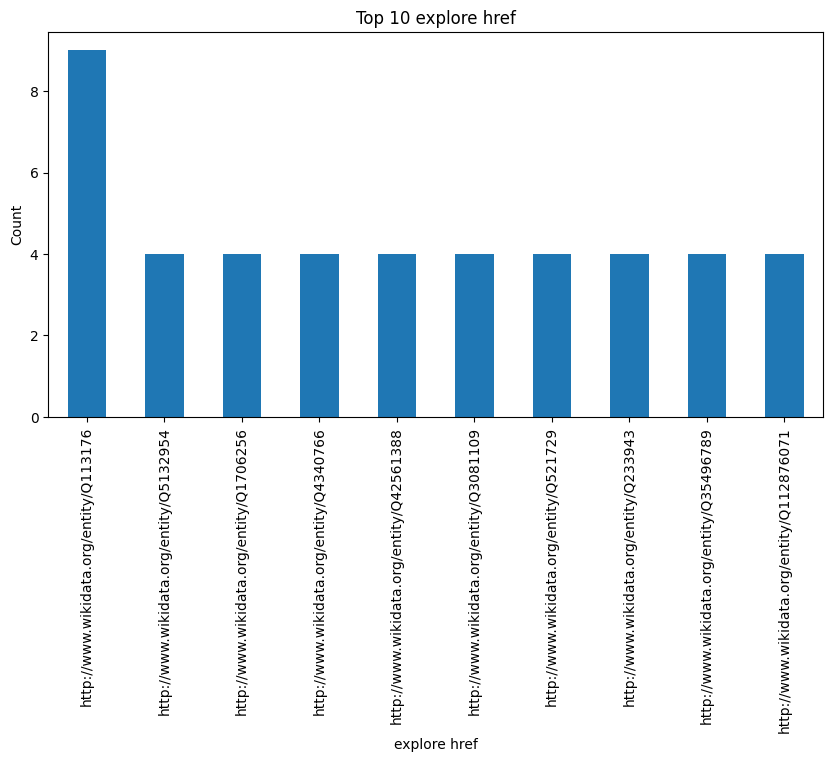

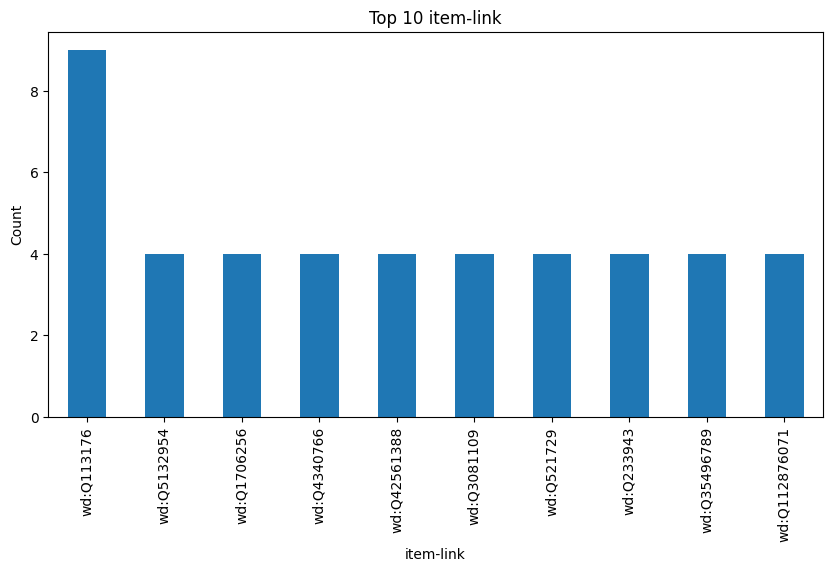

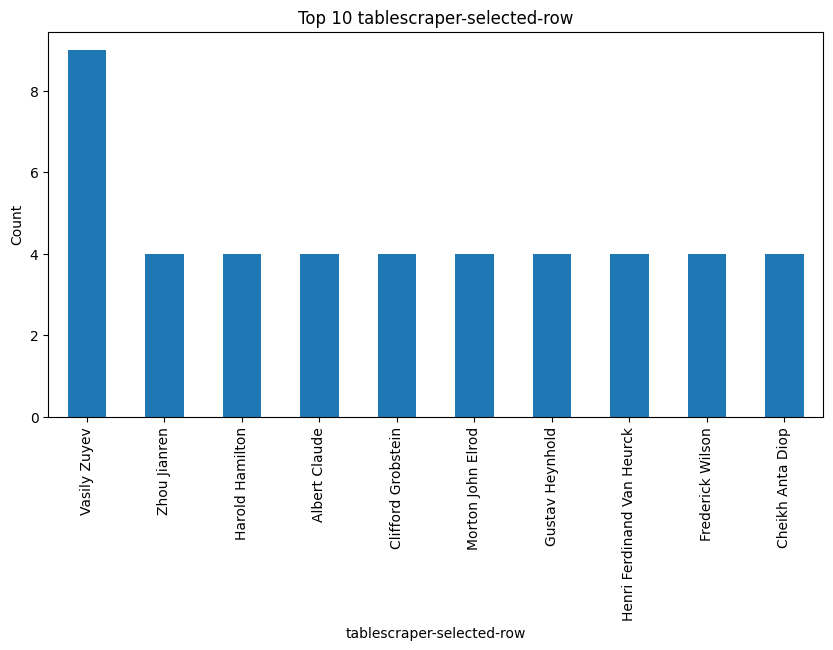

In [2]:
# Example: Frequency of the most common categories (assuming columns like 'Nationality' or 'Field' exist)
# This is a generic check; please adjust column names if they differ
for col in df.select_dtypes(include=['object']).columns[:3]:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top 10 {col}')
    plt.ylabel('Count')
    plt.show()

### Network Science Analysis
We will create a network graph. For example, connecting biologists if they share the same nationality or field of study.

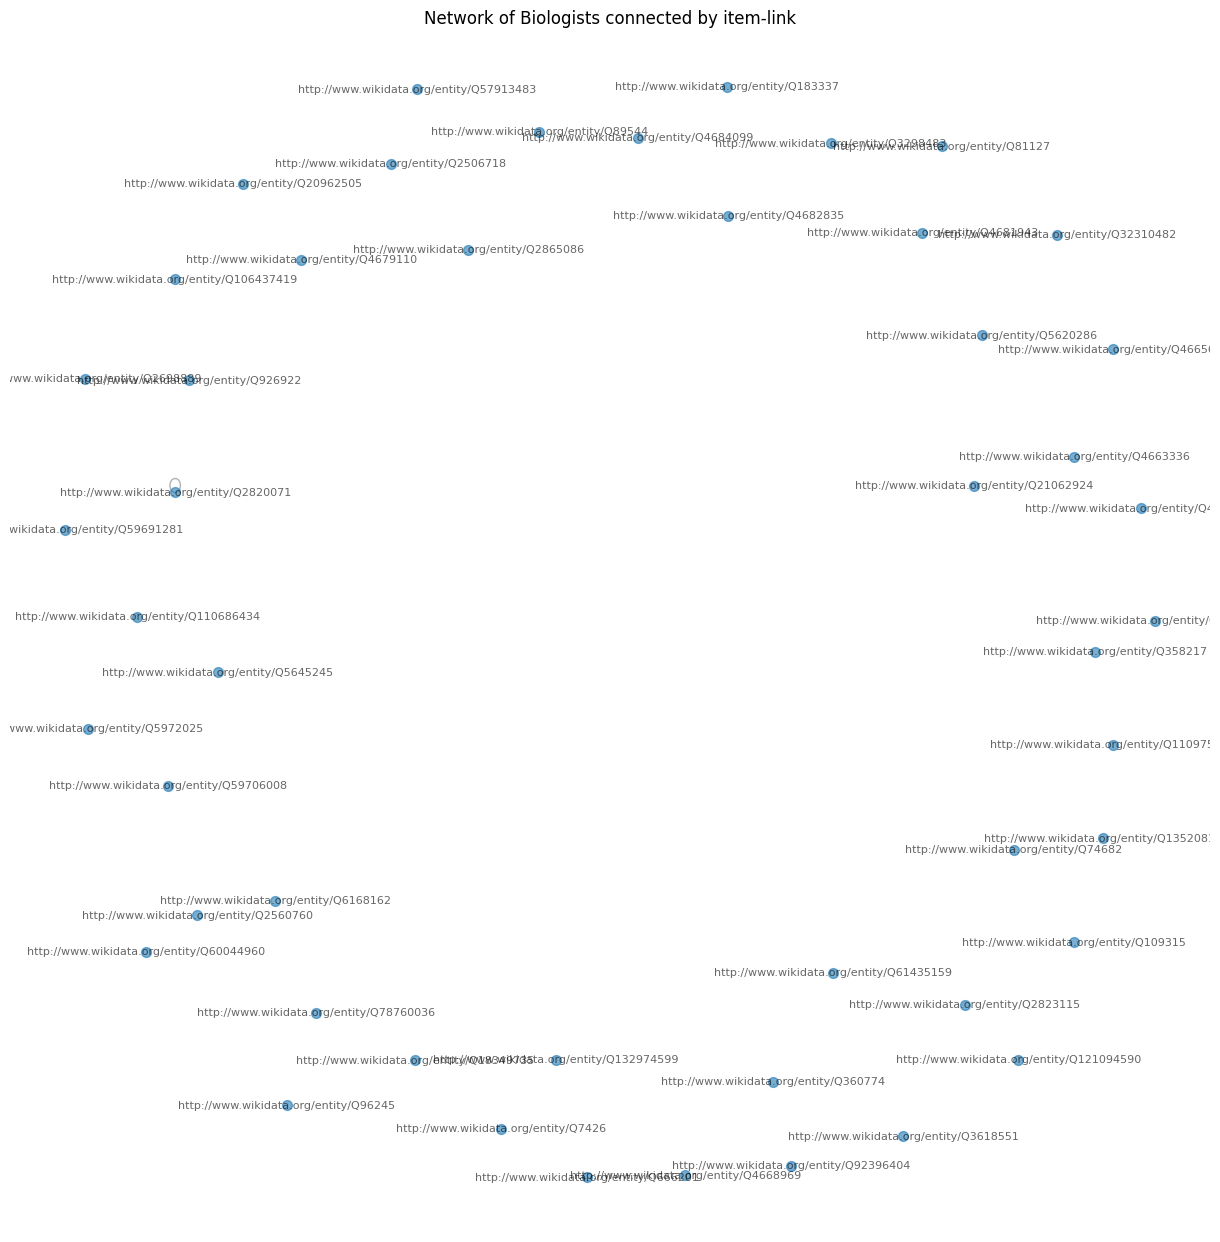

In [3]:
# Create a network based on shared attributes
G = nx.Graph()

# Taking a subset for visualization clarity if the dataset is large
subset_df = df.head(50)

for i, row in subset_df.iterrows():
    G.add_node(row[df.columns[0]], label='Biologist')

# Example: Connect if they share the same first categorical column value
attr_col = df.select_dtypes(include=['object']).columns[1]
for i, row1 in subset_df.iterrows():
    for j, row2 in subset_df.iterrows():
        if i < j and row1[attr_col] == row2[attr_col]:
            G.add_edge(row1[df.columns[0]], row2[df.columns[0]])

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw(G, pos, with_labels=True, node_size=50, font_size=8, edge_color='gray', alpha=0.6)
plt.title(f'Network of Biologists connected by {attr_col}')
plt.show()

### Advanced Network Analysis: Clustering by Era
We will now extract the birth year from the data to cluster biologists by their historical decade.

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re

# This cell requires the 'df' variable from the first cell
if 'df' in locals() or 'df' in globals():
    def extract_year(date_str):
        if pd.isna(date_str):
            return None
        match = re.search(r'\d{4}', str(date_str))
        return int(match.group()) if match else None

    # Extract birth year and decade for temporal clustering
    df['birth_year'] = df['tablescraper-selected-row 2'].apply(extract_year)
    df['decade'] = (df['birth_year'] // 10) * 10

    # Create a new graph
    G_era = nx.Graph()

    # Filter for rows with valid decades and take a sample for a readable graph
    plot_df = df.dropna(subset=['decade']).head(100)

    for _, row in plot_df.iterrows():
        raw_name = str(row['item-link 2']).replace('<', '').replace('>', '').split('/')[-1]
        name = raw_name.replace('_', ' ')
        G_era.add_node(name, decade=int(row['decade']))

    # Connect biologists born in the same decade
    biologists = list(G_era.nodes())
    for i in range(len(biologists)):
        for j in range(i + 1, len(biologists)):
            b1, b2 = biologists[i], biologists[j]
            if G_era.nodes[b1]['decade'] == G_era.nodes[b2]['decade']:
                G_era.add_edge(b1, b2)

    # Visualize the clusters
    plt.figure(figsize=(15, 10))
    decades = [G_era.nodes[node]['decade'] for node in G_era.nodes()]
    pos = nx.spring_layout(G_era, k=0.15, iterations=100, seed=42)

    scatter = nx.draw_networkx_nodes(G_era, pos, node_color=decades, cmap=plt.cm.Spectral, node_size=150, alpha=0.9)
    nx.draw_networkx_edges(G_era, pos, alpha=0.1, edge_color='black')
    nx.draw_networkx_labels(G_era, pos, font_size=8, font_weight='bold')

    plt.colorbar(scatter, label='Birth Decade')
    plt.title('Graph Theory: Biologists Clustered by Contemporary Eras (Birth Decade)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Dataframe 'df' not found. Please run the data loading cell at the top of the notebook first.")

Dataframe 'df' not found. Please run the data loading cell at the top of the notebook first.
